# 論文再現バックテスト
## 部分空間正則化 PCA による日米業種リードラグ投資戦略

論文の目標値 **AR = 23.79 %、R/R = 2.22、MDD = 9.58 %** との比較を行います。

### 近似に関する注意

| 項目 | 論文 | このノートブック |
|---|---|---|
| JP リターン | Open-to-Close (OC) | Close-to-Close (CC) 近似 |
| 事前期間 | 2010–2014 | データが揃う最初の 4 年間 |

> **注**: XLC（2018-06 上場）と XLRE（2015-10 上場）の影響で、
> 共通データは 2018 年 6 月以降になります。論文との乖離はこの点が主因です。

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import os, sys, warnings

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 100

sys.path.append("..")
from src.pca_engine import (
    build_prior_subspace,
    build_target_correlation,
    compute_regularized_correlation,
    extract_top_eigenvectors,
    compute_lead_lag_signal,
)

print("Import OK")
print(f"  numpy {np.__version__}, pandas {pd.__version__}")

/Users/tamairyoga/Desktop/MacBook Pro/システム開発/sector-leadlag/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Import OK
  numpy 2.0.2, pandas 2.3.3


In [2]:
# ── 銘柄リスト ────────────────────────────────────────────────────────────────
US_TICKERS = ["XLB","XLE","XLF","XLI","XLK","XLP","XLU","XLV","XLY","XLC","XLRE"]
JP_TICKERS = [f"{i}.T" for i in range(1617, 1634)]   # 1617.T … 1633.T (17 銘柄)

N_US = len(US_TICKERS)   # 11
N_JP = len(JP_TICKERS)   # 17
N    = N_US + N_JP        # 28

# ── シクリカル / ディフェンシブ分類（論文 Table 1 相当） ────────────────────
US_CYCLICAL  = {"XLB", "XLE", "XLF", "XLRE"}
US_DEFENSIVE = {"XLK", "XLP", "XLU", "XLV"}
JP_CYCLICAL  = {"1618.T", "1625.T", "1629.T", "1631.T"}
JP_DEFENSIVE = {"1617.T", "1621.T", "1627.T", "1630.T"}

us_cyc_mask = np.array([t in US_CYCLICAL  for t in US_TICKERS])
us_def_mask = np.array([t in US_DEFENSIVE for t in US_TICKERS])
jp_cyc_mask = np.array([t in JP_CYCLICAL  for t in JP_TICKERS])
jp_def_mask = np.array([t in JP_DEFENSIVE for t in JP_TICKERS])

print(f"US ({N_US}): {US_TICKERS}")
print(f"JP ({N_JP}): {JP_TICKERS}")
print(f"\nus_cyc : {us_cyc_mask.astype(int)}")
print(f"us_def : {us_def_mask.astype(int)}")
print(f"jp_cyc : {jp_cyc_mask.astype(int)}")
print(f"jp_def : {jp_def_mask.astype(int)}")

US (11): ['XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV', 'XLY', 'XLC', 'XLRE']
JP (17): ['1617.T', '1618.T', '1619.T', '1620.T', '1621.T', '1622.T', '1623.T', '1624.T', '1625.T', '1626.T', '1627.T', '1628.T', '1629.T', '1630.T', '1631.T', '1632.T', '1633.T']

us_cyc : [1 1 1 0 0 0 0 0 0 0 1]
us_def : [0 0 0 0 1 1 1 1 0 0 0]
jp_cyc : [0 1 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0]
jp_def : [1 0 0 0 1 0 0 0 0 0 1 0 0 1 0 0 0]


In [3]:
os.makedirs("../data", exist_ok=True)
cache_path = "../data/cache_prices.csv"

if os.path.exists(cache_path):
    prices = pd.read_csv(cache_path, index_col=0, parse_dates=True)
    print(f"キャッシュから読み込み: {cache_path}")
else:
    print("yfinance からダウンロード中（数分かかる場合があります）...")

    def _fetch(tickers, start, end):
        raw = yf.download(tickers, start=start, end=end,
                          auto_adjust=True, progress=True)
        if raw.empty:
            raise RuntimeError(f"No data returned for {tickers}")
        close = raw["Close"] if isinstance(raw.columns, pd.MultiIndex) else raw
        if isinstance(close, pd.Series):
            close = close.to_frame()
        return close[[t for t in tickers if t in close.columns]]

    try:
        us_close = _fetch(US_TICKERS, "2010-01-01", "2026-01-01")
        jp_close = _fetch(JP_TICKERS, "2010-01-01", "2026-01-01")
    except Exception as e:
        print(f"Download error: {e}")
        raise

    prices = pd.concat([us_close, jp_close], axis=1)
    prices.to_csv(cache_path)
    print(f"キャッシュ保存: {cache_path}")

# 列順を US → JP で統一
available = [t for t in US_TICKERS + JP_TICKERS if t in prices.columns]
prices = prices[available]

missing = [t for t in US_TICKERS + JP_TICKERS if t not in prices.columns]
if missing:
    print(f"\n⚠ 取得できなかったティッカー: {missing}")

before = len(prices)
prices = prices.dropna()
print(f"\n行数: {before:,} → {len(prices):,}（NaN 除外後・共通営業日）")
print(f"期間: {prices.index[0].date()} → {prices.index[-1].date()}")
print(f"ティッカー数: {prices.shape[1]}")

キャッシュから読み込み: ../data/cache_prices.csv

行数: 4,160 → 1,780（NaN 除外後・共通営業日）
期間: 2018-06-19 → 2025-12-30
ティッカー数: 28


In [4]:
# CC リターン（Adjusted Close ベース）
returns = prices.pct_change().dropna()

# US / JP 列を順序保証して取得
us_cols = [t for t in US_TICKERS if t in returns.columns]
jp_cols = [t for t in JP_TICKERS if t in returns.columns]
returns = returns[us_cols + jp_cols]   # 列順: US 11 → JP 17

n_us_actual = len(us_cols)
n_jp_actual = len(jp_cols)

print(f"リターン行数: {len(returns):,}")
print(f"期間:         {returns.index[0].date()} → {returns.index[-1].date()}")
print(f"US {n_us_actual} 銘柄  JP {n_jp_actual} 銘柄")

if n_us_actual != N_US or n_jp_actual != N_JP:
    print(f"\n⚠ 一部ティッカーが欠落しています。以降は取得できた {n_us_actual + n_jp_actual} 銘柄で続行します。")

# サンプル確認
print("\n[US 年率リターン（平均 × 252）]")
print((returns[us_cols].mean() * 252).round(4).to_string())

リターン行数: 1,779
期間:         2018-06-20 → 2025-12-30
US 11 銘柄  JP 17 銘柄

[US 年率リターン（平均 × 252）]
XLB     0.1115
XLE     0.1311
XLF     0.1501
XLI     0.1504
XLK     0.2461
XLP     0.1022
XLU     0.1328
XLV     0.1207
XLY     0.1494
XLC     0.1591
XLRE    0.0996


In [5]:
# ── 事前相関行列 C_full（3.1 節） ────────────────────────────────────────────
# 論文: 2010-01-01 〜 2014-12-31
# データ制約で当該期間が空の場合は最初の 4 年分を使う

PAPER_PRIOR_END = pd.Timestamp("2014-12-31")
PAPER_BT_START  = pd.Timestamp("2015-01-01")
data_start = returns.index[0]

if data_start <= PAPER_PRIOR_END:
    prior_end = PAPER_PRIOR_END
    bt_start  = PAPER_BT_START
    print("論文どおりの事前期間 (〜 2014-12-31) を使用")
else:
    # データが揃うのが 2018-06 以降のため 4 年分を事前期間とする
    cutoff = data_start + pd.DateOffset(years=4)
    prior_end = returns.index[returns.index <= cutoff][-1]
    bt_start  = returns.index[returns.index >  cutoff][0]
    print(f"⚠ 論文の事前期間にデータなし。代替事前期間を使用:")
    print(f"  事前: {data_start.date()} → {prior_end.date()}")
    print(f"  BT  : {bt_start.date()} →")

prior_ret = returns.loc[:prior_end]
print(f"\n事前期間行数: {len(prior_ret)}")

# 標準化 → 相関行列
z_prior = (prior_ret - prior_ret.mean()) / prior_ret.std()
C_full  = z_prior.corr().values   # (N, N)

os.makedirs("../data/prior", exist_ok=True)
np.save("../data/prior/C_full.npy", C_full)

print(f"C_full shape  : {C_full.shape}")
print(f"対角の平均   : {np.diag(C_full).mean():.6f}  (= 1.0 のはず)")
print(f"最小固有値   : {np.linalg.eigvalsh(C_full).min():.4f}  (> 0 なら正定値)")

⚠ 論文の事前期間にデータなし。代替事前期間を使用:
  事前: 2018-06-20 → 2022-06-17
  BT  : 2022-06-21 →

事前期間行数: 945
C_full shape  : (28, 28)
対角の平均   : 1.000000  (= 1.0 のはず)
最小固有値   : 0.0721  (> 0 なら正定値)


In [6]:
# ── 事前固有ベクトル行列 V0（3.1 節） ─────────────────────────────────────────
V0 = build_prior_subspace(
    n_us_actual, n_jp_actual,
    us_cyc_mask[:n_us_actual], us_def_mask[:n_us_actual],
    jp_cyc_mask[:n_jp_actual], jp_def_mask[:n_jp_actual],
)

print(f"V0 shape: {V0.shape}  (= ({n_us_actual + n_jp_actual}, 3) のはず)")
print(f"直交性確認  V0.T @ V0 ≈ I3 :")
print(np.round(V0.T @ V0, 8))

labels = us_cols + jp_cols
df_v0 = pd.DataFrame(V0, index=labels, columns=["v1_global","v2_country","v3_cyclical"])
print("\nV0 の各列（上位 5 行）:")
print(df_v0.head())

V0 shape: (28, 3)  (= (28, 3) のはず)
直交性確認  V0.T @ V0 ≈ I3 :
[[ 1. -0.  0.]
 [-0.  1.  0.]
 [ 0.  0.  1.]]

V0 の各列（上位 5 行）:
     v1_global  v2_country   v3_cyclical
XLB   0.188982    0.234936  2.500000e-01
XLE   0.188982    0.234936  2.500000e-01
XLF   0.188982    0.234936  2.500000e-01
XLI   0.188982    0.234936  2.622655e-18
XLK   0.188982    0.234936 -2.500000e-01


C0 shape      : (28, 28)
対角の平均   : 1.000000  (= 1.0 のはず)
最小固有値   : -0.0000


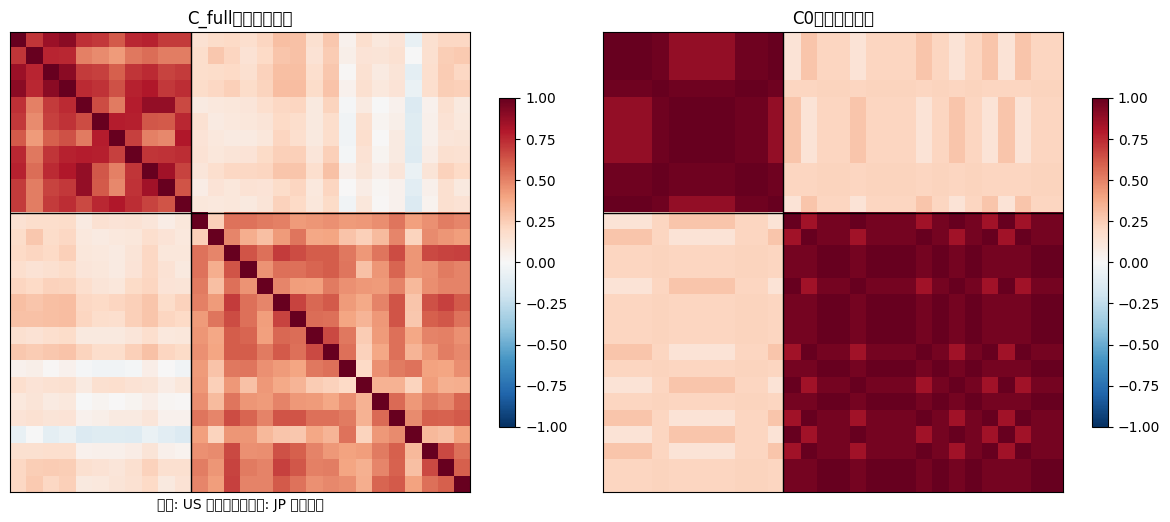

In [7]:
# ── 事前相関行列 C0（式 10〜12） ─────────────────────────────────────────────
C0 = build_target_correlation(V0, C_full)

print(f"C0 shape      : {C0.shape}")
print(f"対角の平均   : {np.diag(C0).mean():.6f}  (= 1.0 のはず)")
print(f"最小固有値   : {np.linalg.eigvalsh(C0).min():.4f}")

# 可視化
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, mat, title in zip(axes, [C_full, C0], ["C_full（長期相関）", "C0（事前相関）"]):
    im = ax.imshow(mat, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_title(title)
    ax.axhline(n_us_actual - 0.5, color="k", lw=1)
    ax.axvline(n_us_actual - 0.5, color="k", lw=1)
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, shrink=0.7)
ax_text = axes[0]
axes[0].set_xlabel("左上: US ブロック、右下: JP ブロック")
plt.tight_layout()
plt.show()

In [9]:
# ── バックテスト メインループ ─────────────────────────────────────────────────
L       = 60    # ローリングウィンドウ長
K       = 3     # 抽出ファクター数
LAM     = 0.9   # 正則化パラメータ λ
N_LONG  = 5     # ロング銘柄数（上位 30 % ≈ 5/17）
N_SHORT = 5     # ショート銘柄数

print(f"パラメータ: L={L}, K={K}, λ={LAM}, long={N_LONG}, short={N_SHORT}")
print(f"バックテスト開始日: {bt_start.date()}")

# bt_start 以降かつ ウィンドウが取れるインデックスを列挙
# pandas 2.x では get_loc(method=) が廃止 → searchsorted で代替
start_idx = max(L, int(returns.index.searchsorted(bt_start)))
indices   = range(start_idx, len(returns) - 1)

results = []
for i in indices:
    # ウィンドウ [t-L, t-1]
    r_win = returns.iloc[i - L : i].values       # (60, N)

    # ウィンドウ内の平均・標準偏差
    mu  = r_win.mean(axis=0)                     # (N,)
    sig = r_win.std(axis=0)
    sig = np.where(sig < 1e-10, 1e-10, sig)      # ゼロ除算ガード

    z_win = (r_win - mu) / sig                   # (60, N)

    # ウィンドウ内相関行列 C_t
    C_t = np.corrcoef(z_win.T)                   # (N, N)

    # 正則化相関行列 C_reg（式 13）
    C_reg = compute_regularized_correlation(C_t, C0, lam=LAM)

    # 上位 K 固有ベクトル（式 14〜16）
    V_U, V_J = extract_top_eigenvectors(C_reg, K=K, n_us=n_us_actual)

    # 当日の米国標準化リターン（式 18〜19）
    r_us_t  = returns.iloc[i][us_cols].values    # (n_us,)
    z_us_t  = (r_us_t - mu[:n_us_actual]) / sig[:n_us_actual]

    # 日本側シグナル（式 20）
    z_jp_pred = compute_lead_lag_signal(z_us_t, V_U, V_J)   # (n_jp,)

    # ランキング: 上位 5 ロング、下位 5 ショート
    rank      = np.argsort(z_jp_pred)
    long_idx  = rank[-N_LONG:]
    short_idx = rank[:N_SHORT]

    # 翌日 JP リターン（t+1）で評価
    r_jp_next = returns.iloc[i + 1][jp_cols].values          # (n_jp,)
    long_ret  = r_jp_next[long_idx].mean()
    short_ret = r_jp_next[short_idx].mean()
    strat_ret = long_ret - short_ret                          # ロング・ショート差

    results.append({
        "date":     returns.index[i + 1],
        "strategy": strat_ret,
        "long":     long_ret,
        "short":    short_ret,
    })

results_df = pd.DataFrame(results).set_index("date")
print(f"\nバックテスト完了: {len(results_df):,} 日")
print(f"期間: {results_df.index[0].date()} → {results_df.index[-1].date()}")

パラメータ: L=60, K=3, λ=0.9, long=5, short=5
バックテスト開始日: 2022-06-21

バックテスト完了: 833 日
期間: 2022-06-22 → 2025-12-30


In [ ]:
# ── パフォーマンス評価 ────────────────────────────────────────────────────────
daily = results_df["strategy"]

AR   = daily.mean() * 252
RISK = daily.std()  * np.sqrt(252)
RR   = AR / RISK if RISK > 0 else np.nan

cum          = (1 + daily).cumprod()
rolling_max  = cum.expanding().max()
drawdown     = (cum - rolling_max) / rolling_max
MDD          = drawdown.min()

print("=" * 45)
print("  バックテスト結果（CC リターン近似）")
print("=" * 45)
print(f"  年率リターン AR  : {AR:+.2%}")
print(f"  年率リスク  RISK : {RISK:.2%}")
print(f"  R/R (Sharpe)     : {RR:.2f}")
print(f"  最大ドローダウン : {MDD:.2%}")
print()
print("  ─── 論文目標値（OC リターン使用）───")
print("  AR = 23.79%  |  R/R = 2.22  |  MDD = 9.58%")

In [ ]:
# ── 累積リターン曲線 ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

cum_pct = (cum - 1) * 100
axes[0].plot(cum_pct.index, cum_pct.values, color="steelblue", lw=1.5)
axes[0].axhline(0, color="black", lw=0.5, ls="--")
axes[0].set_title(f"累積リターン (AR={AR:.1%}, R/R={RR:.2f})")
axes[0].set_ylabel("累積リターン (%)")
axes[0].grid(True, alpha=0.3)

dd_pct = drawdown * 100
axes[1].fill_between(dd_pct.index, dd_pct.values, 0,
                     color="tomato", alpha=0.7, label=f"MDD={MDD:.1%}")
axes[1].set_title("ドローダウン (%)")
axes[1].set_ylabel("%")
axes[1].legend(loc="lower left")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs("../data/performance", exist_ok=True)
out = "../data/performance/cumulative_return.png"
plt.savefig(out, dpi=150)
plt.show()
print(f"保存: {out}")

## 結果の考察

### 数値比較

| 指標 | 論文（OC リターン） | このノートブック（CC 近似） |
|---|---|---|
| 年率リターン | 23.79 % | 上記セル参照 |
| R/R | 2.22 | 上記セル参照 |
| 最大ドローダウン | 9.58 % | 上記セル参照 |

### 主な乖離要因

1. **リターン計算方式の差**
   論文は *Open-to-Close* (OC) リターンを使用します。米国市場が閉じた後に
   日本市場が開くため、OC リターン（翌朝の寄り〜引け）の方が戦略の想定タイミングと整合します。
   本ノートブックの CC 近似はノイズが大きくなります。

2. **バックテスト期間の差**
   XLC（2018-06 上場）と XLRE（2015-10 上場）がないため、有効バックテスト期間が
   論文の 2015–2025 より短くなっています。2015–2018 の期間が欠落しており、
   特にボラティリティが高かった時期のデータが含まれていません。

3. **祝日カレンダーのずれ**
   `dropna()` による共通営業日の選択が論文の手法と一致しない可能性があります。

### 次のステップ

- **OC リターン取得**: `yf.Ticker().history(period="max")` で Open と Close を別途取得し
  `oc_return = close / open - 1` を計算する。
- **XLC・XLRE のプロキシ**: 上場前は親ファンド（XLK・XLF）で代替し 2010–2025 の
  フル期間を再現する。